<hr style='border-top:4px solid #1F77B4;'>

<h2><span style="color: #1F77B4; font-size: 35px">Chapitre 12</span></h2>
<h1><span style="color: #1F77B4; font-size: 50px">Techniques de regroupement</span></h1>

Ce carnet reprend, dans l'ordre du chapitre, l'ensemble des extraits de code présentés dans le texte et permet de régénérer les figures associées selon les conventions graphiques du livre. Il couvre notamment $k$-means, $k$-medoids, le regroupement flou, le regroupement hiérarchique, DBSCAN et les principales métriques d'évaluation des regroupements. Le fil conducteur applicatif est le jeu de données <i>Wholesale Customers</i>, complété par des données synthétiques lorsque la démonstration l'exige. Les cellules doivent être exécutées séquentiellement, car certaines réutilisent des variables ou des résultats définis en amont.

**Bibliothèques requises** : `numpy`, `pandas`, `matplotlib`, `scipy`, `scikit-learn` (≥ 1.6), `kmedoids` et `scikit-fuzzy`.  
**Installation complémentaire** : `kmedoids` et `scikit-fuzzy` s'installent avec `pip install kmedoids scikit-fuzzy`.  
**Données externes** : le fichier `./data/Wholesale customers data.csv` doit se trouver dans le sous-dossier `data`.  
**Exécution** : les versions utilisées sont affichées par la cellule de configuration.

<hr style='border-top:4px solid #1F77B4;'>

In [1]:
# Configuration générale : bibliothèques, versions et affichage
import sys
import os

from importlib.metadata import version as package_version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PAQUETS = ('numpy', 'pandas', 'matplotlib', 'scipy', 'scikit-learn', 'kmedoids', 'scikit-fuzzy')

print(f"{'python':<18} {sys.version.split()[0]}")
for paquet in PAQUETS:
    print(f"{paquet:<18} {package_version(paquet)}")

plt.rcParams.update({
    'font.size': 13,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'mathtext.fontset': 'cm',
    'text.usetex': False,
})

# Couleurs du livre (palette viridis)
VIOLET, SARCELLE, VERT, BLEU, MAGENTA = '#482878', '#21918c', '#5ec962', '#3b528b', '#bf00bf'
BORD    = {VIOLET: '#2e1a4d', SARCELLE: '#14615d', VERT: '#3a7d3f', BLEU: '#2c3e6b', MAGENTA: '#8a008a'}
PALETTE = [VIOLET, SARCELLE, VERT, BLEU, MAGENTA]

os.environ["OMP_NUM_THREADS"] = "2"

python             3.12.13
numpy              2.5.1
pandas             3.0.3
matplotlib         3.11.0
scipy              1.18.0
scikit-learn       1.9.0
kmedoids           0.5.5
scikit-fuzzy       0.5.0


In [2]:
# Fonction utilitaire de sauvegarde des figures (PDF)
import os

def save_figure(fig, path):
    directory = os.path.dirname(path)
    if directory:
        os.makedirs(directory, exist_ok=True)
    fig.savefig(f"{path}.pdf", format="pdf", bbox_inches='tight')

<hr style='border-top:4px solid #1F77B4;'>

<h3><span style="font-size: 30px">&#127924;</span> Figure : Compacité et séparation comparées</h3>

Compacité et séparation selon la dispersion
                        C_intra     S_inter
-------------------------------------------------------
(a) Clusters compacts   1.20        10.93
(b) Clusters dispersés  4.79        10.95



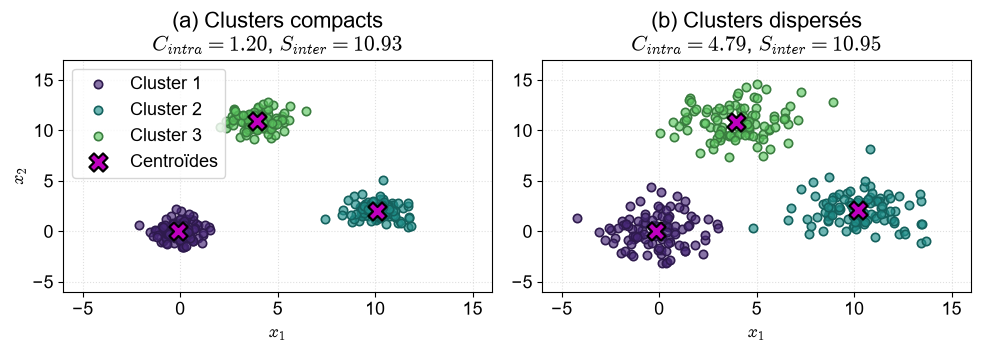

In [3]:
from sklearn.datasets import make_blobs
from matplotlib.colors import to_rgba

def compacite(X, etiquettes, centres):
    """Compacité intra-cluster : distance quadratique moyenne au centroïde."""
    return np.mean(np.sum((X - centres[etiquettes]) ** 2, axis=1))

def separation(centres):
    """Séparation inter-clusters : distance moyenne entre centroïdes."""
    d = [np.linalg.norm(centres[k] - centres[l])
         for k in range(len(centres)) for l in range(k + 1, len(centres))]
    return np.mean(d)

centres_vrais = np.array([[0, 0], [10, 2], [4, 11]])

# --- Calculs ---
resultats = []
for ecart, titre in [(0.8, '(a) Clusters compacts'),
                     (1.6, '(b) Clusters dispersés')]:
    X, e = make_blobs(n_samples=300, centers=centres_vrais,
                      cluster_std=ecart, random_state=42)
    centres = np.array([X[e == k].mean(axis=0) for k in range(3)])
    resultats.append((titre, X, e, centres,
                      compacite(X, e, centres), separation(centres)))

# --- Affichage ---
L = 55
print("=" * L)
print("Compacité et séparation selon la dispersion")
print("=" * L)
print(f"{'':<24}{'C_intra':<12}{'S_inter'}")
print("-" * L)
for titre, X, e, centres, c_intra, s_inter in resultats:
    print(f"{titre:<24}{c_intra:<12.2f}{s_inter:.2f}")
print("=" * L)
print("")

# --- Figure ---
fig, axes = plt.subplots(1, 2, figsize=(10, 3.7))

for ax, (titre, X, e, centres, c_intra, s_inter) in zip(axes, resultats):
    for k in range(3):
        coul = PALETTE[k]
        ax.scatter(X[e == k, 0], X[e == k, 1], color=to_rgba(coul, 0.65),
                   edgecolors=BORD[coul], linewidths=1.2,
                   label=f'Cluster {k + 1}', zorder=3)
    ax.scatter(centres[:, 0], centres[:, 1], marker='X', s=170,
               color=MAGENTA, edgecolors='black', linewidths=1.6,
               label='Centroïdes', zorder=4)

    ax.set_title(f"{titre}\n$C_{{intra}} = {c_intra:.2f}$, "
                 f"$S_{{inter}} = {s_inter:.2f}$")
    ax.set_xlim(-6, 16)
    ax.set_ylim(-6, 17)
    ax.set_xlabel(r"$x_1$")
    ax.grid(alpha=0.4, linestyle=':', zorder=0)

axes[0].set_ylabel(r"$x_2$")
axes[0].legend(loc='upper left')

fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap12_ExempleIntracluster')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 12.1 : Lecture des données <i>Wholesale Customers</i></h3>

In [4]:
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("./data/Wholesale customers data.csv")

# Variables quantitatives retenues
num_cols = ["Fresh", "Milk", "Grocery", "Frozen",
            "Detergents_Paper", "Delicassen"]
X = df[num_cols]

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Dimensions :", X_scaled.shape)

Dimensions : (440, 6)


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 12.2 : Choix du nombre de clusters (coude et silhouette)</h3>

Choix de K : coude et silhouette
K       Inertie       Silhouette
--------------------------------
2       1954.0        0.581
3       1608.4        0.548
4       1316.5        0.344
5       1058.8        0.369
6       915.5         0.377
7       822.2         0.316
8       737.4         0.320


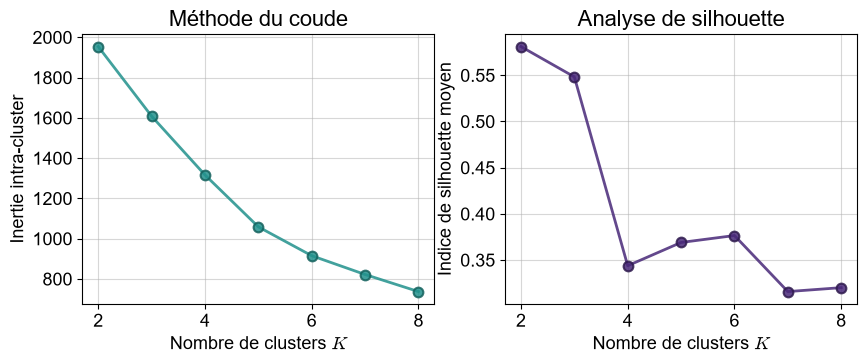

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

liste_K = range(2, 9)
inerties, silhouettes = [], []
for K in liste_K:
    km = KMeans(n_clusters=K, n_init=50, random_state=42).fit(X_scaled)
    inerties.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

# --- Affichage ---
titre = "Choix de K : coude et silhouette"
L = max(30, len(titre))

print("=" * L)
print(titre)
print("=" * L)
print(f"{'K':<8}{'Inertie':<14}{'Silhouette'}")
print("-" * L)
for K, iner, sil in zip(liste_K, inerties, silhouettes):
    print(f"{K:<8}{iner:<14.1f}{sil:.3f}")
print("=" * L)

# --- Figure ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
ax1.plot(list(liste_K), inerties, marker='o', markersize=7, color=SARCELLE,
         markeredgecolor=BORD[SARCELLE], markeredgewidth=1.5, linewidth=2,
         alpha=0.85, zorder=3)
ax1.set_xlabel("Nombre de clusters $K$")
ax1.set_ylabel("Inertie intra-cluster")
ax1.set_title("Méthode du coude")
ax1.grid(alpha=0.5, zorder=0)
ax2.plot(list(liste_K), silhouettes, marker='o', markersize=7, color=VIOLET,
         markeredgecolor=BORD[VIOLET], markeredgewidth=1.5, linewidth=2,
         alpha=0.85, zorder=3)
ax2.set_xlabel("Nombre de clusters $K$")
ax2.set_ylabel("Indice de silhouette moyen")
ax2.set_title("Analyse de silhouette")
ax2.grid(alpha=0.5, zorder=0)

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap12_ChoixK')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 12.3 : Entraînement du modèle <i>k</i>-means</h3>

In [6]:
K = 5
kmeans = KMeans(n_clusters=K, n_init=50, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled) + 1

# Affichage
print("Inertie finale :", round(kmeans.inertia_, 1))

Inertie finale : 1058.8


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 12.4 : Analyse des clusters</h3>

In [7]:
profil = df.groupby("Cluster")[num_cols].mean().round(0)
profil.insert(0, "Taille", df["Cluster"].value_counts().sort_index())

# --- Affichage ---
L = 75
print("=" * L)
print(f"Profil des clusters (K = {K})")
print("=" * L)
print(profil.to_string(float_format=lambda x: f"{x:.0f}"))
print("=" * L)

Profil des clusters (K = 5)
         Taille  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
Cluster                                                                    
1           270   9092  2968     3807    2272               990         979
2            10  15965 34708    48537    3055             24875        2943
3            63  32958  4997     5885    8423               955        2463
4            96   5754 10867    16607    1464              7203        1813
5             1  36847 43950    20170   36534               239       47943


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 12.5 : Profils des clusters </h3>

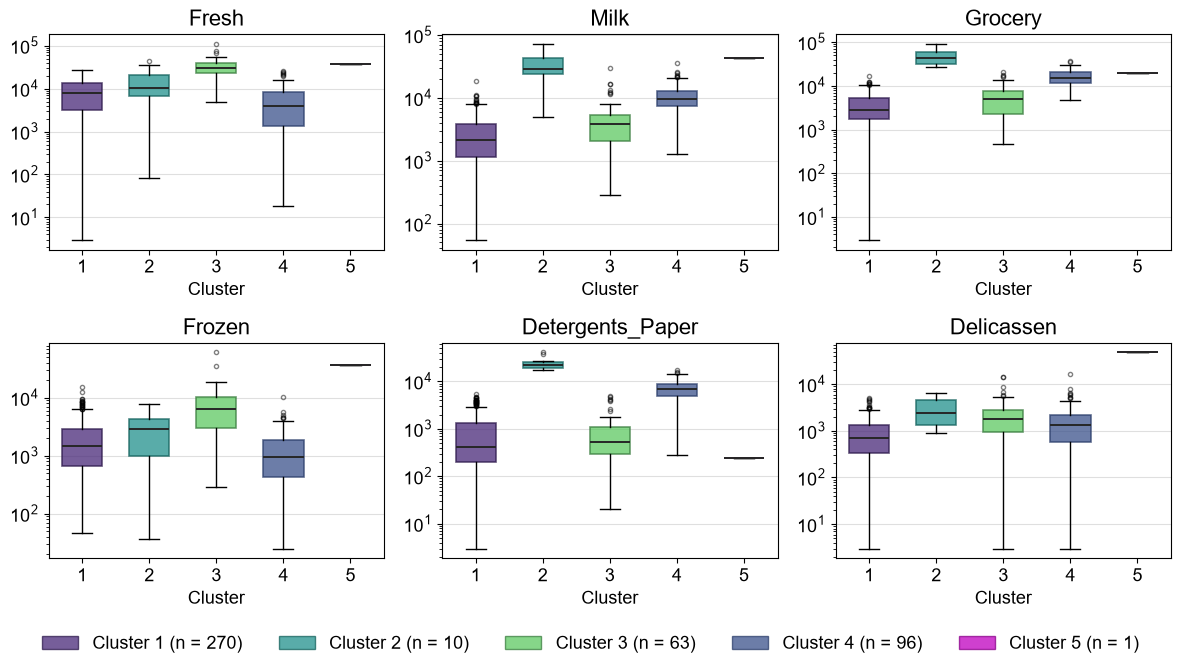

In [8]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for ax, col in zip(axes.ravel(), num_cols):
    donnees = [df.loc[df["Cluster"] == k, col].values for k in range(1, K + 1)]

    bp = ax.boxplot(donnees, patch_artist=True, widths=0.6,
                    medianprops=dict(color='0.15', linewidth=1.4),
                    flierprops=dict(marker='o', markersize=3, alpha=0.5))

    for boite, coul in zip(bp["boxes"], PALETTE):
        boite.set(facecolor=coul, alpha=0.75, edgecolor=BORD.get(coul, '0.2'), linewidth=1.2)

    ax.set_yscale("log")
    ax.set_title(col)
    ax.set_xlabel("Cluster")
    ax.grid(axis="y", alpha=0.4)

# Légende commune : couleurs et effectifs
tailles_clusters = df["Cluster"].value_counts().sort_index()

elements_legende = [
    Patch(
        facecolor=coul,
        edgecolor=BORD.get(coul, '0.2'),
        alpha=0.75,
        label=f"Cluster {k} (n = {tailles_clusters.loc[k]})"
    )
    for k, coul in zip(range(1, K + 1), PALETTE)
]

fig.legend(
    handles=elements_legende,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.03),
    ncol=K,
    frameon=False
)

fig.tight_layout(rect=[0, 0.09, 1, 1])

# Sauvegarder la figure
save_figure(fig, "Figures/Fig_Chap12_InterpretationKmeans")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 12.6 : Effet d'une transformation logarithmique</h3>

In [9]:
X_log = StandardScaler().fit_transform(np.log1p(X))
km_log = KMeans(n_clusters=K, n_init=50, random_state=42).fit(X_log)

tailles_brut = sorted(pd.Series(kmeans.labels_).value_counts(), reverse=True)
tailles_log = sorted(pd.Series(km_log.labels_).value_counts(), reverse=True)

silhouette_brut = silhouette_score(X_scaled, kmeans.labels_)
silhouette_log = silhouette_score(X_log, km_log.labels_)

# --- Affichage ---
titre = "Effet de la transformation logarithmique"
L = max(30, len(titre))
largeur = 12

print("=" * L)
print(titre)
print("=" * L)
print(" " * 12 + "Sans log".rjust(largeur) + "Avec log".rjust(largeur))
print(f"{'Silhouette':<12}" f"{silhouette_brut:>{largeur}.3f}" f"{silhouette_log:>{largeur}.3f}")
print("-" * L)
print("Tailles des clusters (ordre décroissant)")
print(f"{'Ordre':<12}" f"{'Sans log':>{largeur}}" f"{'Avec log':>{largeur}}")
for i, (tb, tl) in enumerate(zip(tailles_brut, tailles_log), start=1):
    print(f"{i:<12}{tb:>{largeur}}{tl:>{largeur}}")
print("=" * L)

Effet de la transformation logarithmique
                Sans log    Avec log
Silhouette         0.369       0.192
----------------------------------------
Tailles des clusters (ordre décroissant)
Ordre           Sans log    Avec log
1                    270         100
2                     96         100
3                     63          96
4                     10          90
5                      1          54


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 12.7 : <i>k</i>-medoids</h3>

%pip install kmedoids

In [10]:
import kmedoids
from sklearn.metrics import pairwise_distances

D = pairwise_distances(X_scaled)

resultat = kmedoids.KMedoids(K, method="fasterpam", random_state=42).fit(D)
medoides = resultat.medoid_indices_.tolist()

# Tailles dans l'ordre des clusters 0, 1, ..., K - 1
tailles = (pd.Series(resultat.labels_).value_counts().reindex(range(K), fill_value=0).tolist())

# --- Affichage ---
tableau = pd.DataFrame(
    [medoides, tailles],
    index=["Indice du médoïde", "Taille du cluster"],
    columns=[f"Cluster {k}" for k in range(1, K + 1)]
)

print("=" * 73)
print(f"K-médoïdes (K = {K})")
print("=" * 73)
print(tableau.to_string())
print("=" * 73)

K-médoïdes (K = 5)
                   Cluster 1  Cluster 2  Cluster 3  Cluster 4  Cluster 5
Indice du médoïde         91        324        197        163        374
Taille du cluster         53         81        113         36        157


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 12.8 : Effet de l'initialisation <i>k</i>-means++</h3>

In [11]:
resultats = []
for init in ['random', 'k-means++']:
    inerties_init = [KMeans(n_clusters=K, init=init, n_init=1,
                            random_state=g).fit(X_scaled).inertia_
                     for g in range(20)]
    moyenne = np.mean(inerties_init)
    ecart_type = np.std(inerties_init)
    minimum = min(inerties_init)
    resultats.append((init, moyenne, ecart_type, minimum))

# --- Affichage ---
titre = "Effet de l'initialisation k-means++"
L = max(45, len(titre))
print("=" * L)
print(titre)
print("=" * L)
print(f"{'Init':<12}{'Moyenne':<12}{'Écart-type':<14}{'Minimum'}")
print("-" * L)
for init, moy, ect, mn in resultats:
    print(f"{init:<12}{moy:<12.1f}{ect:<14.1f}{mn:.1f}")
print("=" * L)

Effet de l'initialisation k-means++
Init        Moyenne     Écart-type    Minimum
---------------------------------------------
random      1167.2      76.9          1069.7
k-means++   1109.7      72.9          1058.8


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 12.9 : Regroupement flou (<i>Fuzzy C-means</i>)</h3>

%pip install -U scikit-fuzzy

In [12]:
import skfuzzy as fuzz

centres, u, *_ = fuzz.cluster.cmeans(X_scaled.T, c=K, m=2.0,
                                     error=0.005, maxiter=1000, seed=42)
appartenance_max = u.max(axis=0)
moyenne_app = appartenance_max.mean()
n_ambigues = (appartenance_max < 0.5).sum()

# --- Affichage ---
titre = "Regroupement flou (Fuzzy C-means)"
L = max(58, len(titre))

print("=" * L)
print(titre)
print("=" * L)
print(f"{'Dimensions de la matrice d\'appartenance u':<50}{u.shape}")
print(f"{'Appartenance maximale moyenne':<50}{moyenne_app:.3f}")
print(f"{'Observations d\'appartenance ambiguë (< 0.5)':<50}{n_ambigues}")
print("=" * L)

Regroupement flou (Fuzzy C-means)
Dimensions de la matrice d'appartenance u         (5, 440)
Appartenance maximale moyenne                     0.553
Observations d'appartenance ambiguë (< 0.5)       196


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 12.10 : Dendrogramme</h3>

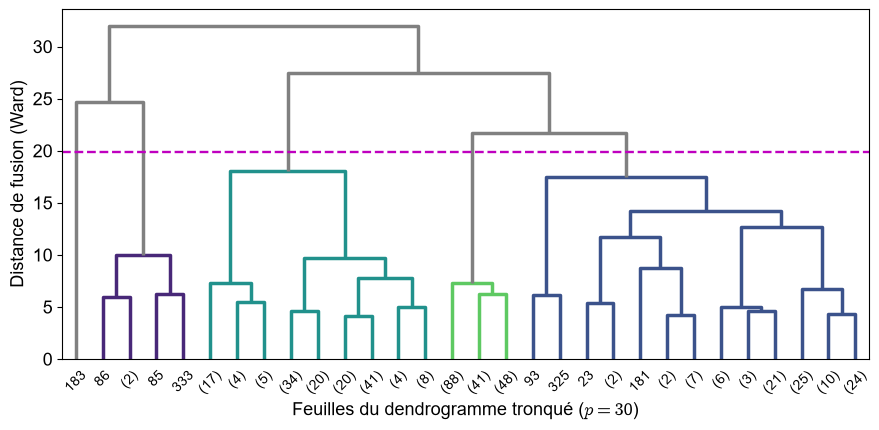

In [13]:
from scipy.cluster.hierarchy import (dendrogram, linkage, fcluster,
                                     set_link_color_palette)

Z = linkage(X_scaled, method='ward')
set_link_color_palette([VIOLET, SARCELLE, VERT, BLEU])

# Seuil donnant K = 5 groupes
seuil_coupe = np.mean([Z[-K, 2], Z[-K + 1, 2]])

fig, ax = plt.subplots(figsize=(9, 4.5))

dendrogram(Z, truncate_mode='lastp', p=30, ax=ax,
           color_threshold=seuil_coupe,
           above_threshold_color='0.5')

# Épaisseur des branches (le dendrogramme dessine des LineCollection)
for branche in ax.collections:
    branche.set_linewidth(2.5)

ax.axhline(seuil_coupe, color=MAGENTA, linestyle='--', linewidth=1.7)
ax.set_xlabel("Feuilles du dendrogramme tronqué ($p = 30$)")
ax.set_ylabel("Distance de fusion (Ward)")
ax.tick_params()
fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap12_Dendrogramme')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 12.11 : Regroupement hiérarchique et comparaison avec <i>k</i>-means</h3>

In [14]:
from sklearn.metrics import adjusted_rand_score

# Coupure de l'arbre en K groupes
etiquettes_hier = fcluster(Z, t=K, criterion='maxclust')
# Concordance avec la partition des k-moyennes
ari = adjusted_rand_score(etiquettes_hier, kmeans.labels_)
tailles_hier = sorted(pd.Series(etiquettes_hier).value_counts(), reverse=True)
tailles_kmeans = sorted(pd.Series(kmeans.labels_).value_counts(), reverse=True)

# --- Affichage ---
titre = "Regroupement hiérarchique et comparaison avec k-means"
L = max(55, len(titre))
largeur = 20

print("=" * L)
print(titre)
print("=" * L)
print("Tailles des clusters (ordre décroissant)")
print(f"{'Ordre':<10}" f"{'Hiérarchique (Ward)':>{largeur}}" f"{'k-means':>{largeur}}")
print("-" * L)
for i, (th, tk) in enumerate(zip(tailles_hier, tailles_kmeans), start=1):
    print(f"{i:<10}{th:>{largeur}}{tk:>{largeur}}")
print("-" * L)
print(f"Indice de Rand ajusté entre les deux partitions : {ari:.3f}")
print("=" * L)

Regroupement hiérarchique et comparaison avec k-means
Tailles des clusters (ordre décroissant)
Ordre      Hiérarchique (Ward)             k-means
-------------------------------------------------------
1                          177                 270
2                          153                  96
3                          104                  63
4                            5                  10
5                            1                   1
-------------------------------------------------------
Indice de Rand ajusté entre les deux partitions : 0.404


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 12.12 : Profils moyens des groupes hiérarchiques</h3>

In [15]:
# Moyennes dans les unités monétaires d'origine
# Les identifiants des groupes renvoyés par fcluster sont conservés.
df_hier = df[num_cols].copy()
df_hier["Ward"] = etiquettes_hier

groupes = df_hier.groupby("Ward")
profil_hier = groupes[num_cols].mean()
profil_hier.insert(0, "Taille", groupes.size())
profil_hier = profil_hier.sort_values("Taille", ascending=False)

# --- Affichage ---
L = 75
print("=" * L)
print(f"Profils des groupes de Ward (K = {K})")
print("=" * L)
print(profil_hier.to_string(float_format=lambda x: f"{x:.0f}"))
print("=" * L)

Profils des groupes de Ward (K = 5)
      Taille  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
Ward                                                                    
4        177   7876  1903     2535    2403               507         744
3        153   5794  9420    13762    1462              5913        1578
5        104  27256  4914     5931    6278              1185        2273
1          5  25603 43461    61472    2636             29974        2709
2          1  36847 43950    20170   36534               239       47943


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 12.13 : Correspondance entre les groupes de Ward et les clusters des $k$-moyennes</h3>

In [16]:
# Nombre de clients communs à chaque paire de groupes
croisement = pd.crosstab(df_hier["Ward"], df["Cluster"], 
                         rownames=["Ward"], colnames=["K-moyennes"])
# Même ordre de lignes que dans le tableau des profils
croisement = croisement.reindex(profil_hier.index)

# --- Affichage ---
L = 43
print("=" * L)
print("Correspondance entre Ward et les k-moyennes")
print("=" * L)
print(croisement.to_string())
print("=" * L)

Correspondance entre Ward et les k-moyennes
K-moyennes    1  2   3   4  5
Ward                         
4           177  0   0   0  0
3            55  5   1  92  0
5            38  0  62   4  0
1             0  5   0   0  0
2             0  0   0   0  1


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 12.14 : DBSCAN sur des clusters non sphériques</h3>

In [17]:
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score

# Deux croissants entrelacés et leurs groupes générés
X_lunes, y_lunes = make_moons(n_samples=300, noise=0.06, random_state=42)

km_lunes = KMeans(n_clusters=2, n_init=50, random_state=42).fit_predict(X_lunes)
db_lunes = DBSCAN(eps=0.2, min_samples=5).fit_predict(X_lunes)
tailles_km = np.bincount(km_lunes).tolist()
tailles_db = np.bincount(db_lunes[db_lunes != -1]).tolist()
n_clusters_db = len(set(db_lunes) - {-1})
ari_km = adjusted_rand_score(y_lunes, km_lunes)
ari_db = adjusted_rand_score(y_lunes, db_lunes)
n_bruit = int((db_lunes == -1).sum())

# --- Affichage ---
n_clusters_km = len(set(km_lunes))
titre = "DBSCAN sur des clusters non sphériques"
largeur = 14
L = max(20 + 2 * largeur, len(titre))

print("=" * L)
print(titre)
print("=" * L)
print(f"{'':<20}{'k-means':>{largeur}}{'DBSCAN':>{largeur}}")
print(f"{'Nombre de clusters':<20}{n_clusters_km:>{largeur}}"
      f"{n_clusters_db:>{largeur}}")
print(f"{'ARI':<20}{ari_km:>{largeur}.3f}{ari_db:>{largeur}.3f}")
print("-" * L)
# print("Taille des clusters")

for i, (tk, td) in enumerate(zip(tailles_km, tailles_db), start=1):
    print(f"{f'Taille Cluster {i}':<20}{tk:>{largeur}}{td:>{largeur}}")

print("-" * L)
print(f"{'Bruit (DBSCAN)':<20}{'':>{largeur}}{n_bruit:>{largeur}}")
print("=" * L)

DBSCAN sur des clusters non sphériques
                           k-means        DBSCAN
Nombre de clusters               2             2
ARI                          0.247         1.000
------------------------------------------------
Taille Cluster 1               151           150
Taille Cluster 2               149           150
------------------------------------------------
Bruit (DBSCAN)                                 0


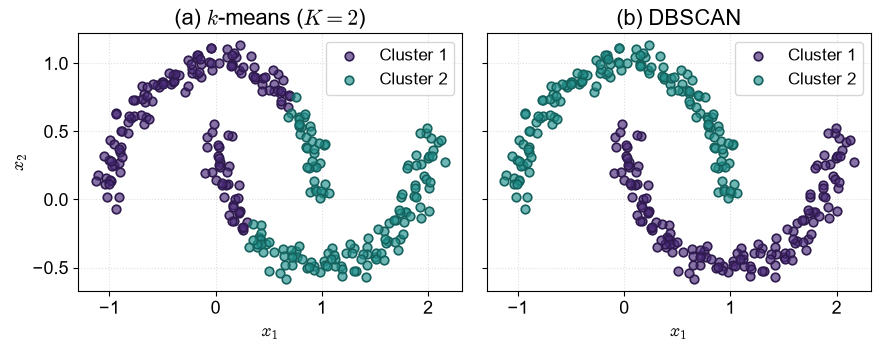

In [18]:
# --- Figure ---
fig, axes = plt.subplots(1, 2, figsize=(9, 3.7), sharey=True)

for ax, etiq, lettre, titre in zip(axes, [km_lunes, db_lunes], 'ab',
                                   ['$k$-means ($K = 2$)', 'DBSCAN']):
    for k in sorted(set(etiq)):
        masque = etiq == k
        if k == -1:
            ax.scatter(X_lunes[masque, 0], X_lunes[masque, 1], s=32,
                       color='0.5', marker='x', linewidths=1.2,
                       label='Bruit', zorder=3)
        else:
            coul = PALETTE[k % len(PALETTE)]
            ax.scatter(X_lunes[masque, 0], X_lunes[masque, 1], s=38,
                       color=to_rgba(coul, 0.65), edgecolors=BORD[coul],
                       linewidths=1.2, label=f'Cluster {k + 1}', zorder=3)

    ax.set_title(f'({lettre}) {titre}')
    ax.set_xlabel('$x_1$')
    ax.tick_params(axis='both')
    ax.grid(alpha=0.4, linestyle=':', zorder=0)
    ax.legend(fontsize=12, loc='upper right')

axes[0].set_ylabel('$x_2$')

fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap12_DBSCAN')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 12.15 : Regroupement de données synthétiques</h3>

In [19]:
from sklearn.datasets import make_blobs

np.random.seed(42)

# Génération de données synthétiques
X_synth, y_vrai = make_blobs(n_samples=300, centers=4, cluster_std=1.2, random_state=42)

# Regroupement en quatre clusters
kmeans_synth = KMeans(n_clusters=4, n_init=50, random_state=42)
y_kmeans = kmeans_synth.fit_predict(X_synth)
print("Dimensions :", X_synth.shape)

Dimensions : (300, 2)


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 12.16 : Métriques d'évaluation des regroupements</h3>

In [20]:
from sklearn.metrics import davies_bouldin_score, pairwise_distances

# Indice de silhouette
silhouette_moy = silhouette_score(X_synth, y_kmeans)

# Cohésion intra-cluster (distance moyenne au centre du cluster)
distances = np.linalg.norm(
    X_synth - kmeans_synth.cluster_centers_[y_kmeans], axis=1)
cohesion = distances.mean()

# Séparation inter-clusters (distance moyenne entre les centres)
d_centres = pairwise_distances(kmeans_synth.cluster_centers_)
np.fill_diagonal(d_centres, np.nan)
separation = np.nanmean(d_centres)

# Indice de Davies-Bouldin
db_index = davies_bouldin_score(X_synth, y_kmeans)

# --- Affichage ---
titre = "Métriques d'évaluation des regroupements"
L = max(40, len(titre))

print("=" * L)
print(titre)
print("=" * L)
print(f"{'Indice de silhouette':<30}{silhouette_moy:.2f}")
print(f"{'Cohésion intra-cluster':<30}{cohesion:.2f}")
print(f"{'Séparation inter-clusters':<30}{separation:.2f}")
print(f"{'Indice de Davies-Bouldin':<30}{db_index:.2f}")
print("=" * L)

Métriques d'évaluation des regroupements
Indice de silhouette          0.75
Cohésion intra-cluster        1.46
Séparation inter-clusters     12.69
Indice de Davies-Bouldin      0.35


<h3><span style="font-size: 30px">&#127924;</span> Figure : Visualisation des clusters</h3>

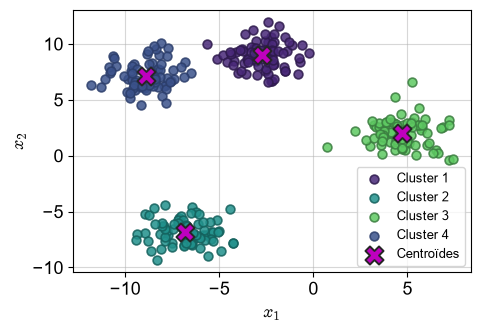

In [21]:
fig, ax = plt.subplots(figsize=(5, 3.5))

for k in range(4):
    masque = y_kmeans == k
    ax.scatter(X_synth[masque, 0], X_synth[masque, 1], s=40, c=PALETTE[k],
               edgecolors=BORD.get(PALETTE[k], '0.2'), linewidths=1.2,
               alpha=0.85, label=f'Cluster {k + 1}', zorder=3)
ax.scatter(kmeans_synth.cluster_centers_[:, 0],
           kmeans_synth.cluster_centers_[:, 1],
           marker='X', s=170, c=MAGENTA, edgecolors='0.15',
           linewidths=1.4, label='Centroïdes', zorder=4)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.grid(alpha=0.5, zorder=0)
ax.legend(fontsize=9, loc='best')
fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap12_plot_clusters')

plt.show()

<hr style='border-top:4px solid #1F77B4;'>